# Neural Control Density Functions — Caltech Ducted Fan


## 1. Imports and device setup

In [29]:
# # -*- coding: utf-8 -*-
# from dreal import *
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import cm
import random
import math

torch.manual_seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 2. Ducted fan dynamics

The dynamics are:
$$
\begin{bmatrix} \dot{x} \\ \dot{y} \\ \dot{\theta} \\ \ddot{x} \\ \ddot{y} \\ \ddot{\theta} \end{bmatrix}
=
\underbrace{\begin{bmatrix} \dot{x} \\ \dot{y} \\ \dot{\theta} \\ -\tfrac{d}{m}\dot{x} \\ -\tfrac{d}{m}\dot{y} - g \\ 0 \end{bmatrix}}_{f(x)}
+
\underbrace{\begin{bmatrix} 0 & 0 \\ 0 & 0 \\ 0 & 0 \\ \tfrac{\cos\theta}{m} & -\tfrac{\sin\theta}{m} \\ \tfrac{\sin\theta}{m} & \tfrac{\cos\theta}{m} \\ \tfrac{r}{I} & 0 \end{bmatrix}}_{g(x)}
\begin{bmatrix} u_0 \\ u_1 \end{bmatrix}
$$

Parameters: $m=11.2$, $r=0.156$, $I=0.0462$, $d=0.1$, $g_\text{grav}=0.28$.

State ordering: $x_0=x$, $x_1=y$, $x_2=\theta$, $x_3=\dot{x}$, $x_4=\dot{y}$, $x_5=\dot{\theta}$.

In [30]:
# Physical parameters
m    = 11.2
r    = 0.156
I    = 0.0462
d    = 0.1
g_grav = 0.28

def f(x):
    """
    Drift vector field f(x) for the ducted fan.
    x: 1D tensor of shape (6,)
    Returns: tensor of shape (6,)
    """
    # x[0]=x_pos, x[1]=y_pos, x[2]=theta, x[3]=xdot, x[4]=ydot, x[5]=thetadot
    f0 = x[3]                        # x_dot  = x_dot
    f1 = x[4]                        # y_dot  = y_dot
    f2 = x[5]                        # theta_dot = theta_dot
    f3 = -(d / m) * x[3]             # x_ddot = -d/m * x_dot
    f4 = -(d / m) * x[4] - g_grav   # y_ddot = -d/m * y_dot - g
    f5 = torch.zeros_like(x[0])      # theta_ddot (unforced part) = 0
    return torch.stack([f0, f1, f2, f3, f4, f5])


def g_matrix(x):
    """
    State-dependent input matrix g(x) for the ducted fan.
    x: 1D tensor of shape (6,)
    Returns: tensor of shape (6, 2)
    """
    theta = x[2]
    zero  = torch.zeros(1, device=x.device).squeeze()

    col0 = torch.stack([
        zero,
        zero,
        zero,
        torch.cos(theta) / m,
        torch.sin(theta) / m,
        torch.tensor(r / I, device=x.device)
    ])
    col1 = torch.stack([
        zero,
        zero,
        zero,
        -torch.sin(theta) / m,
        torch.cos(theta) / m,
        zero
    ])
    return torch.stack([col0, col1], dim=1)  # shape (6, 2)


print("f and g_matrix defined. Quick sanity check at x=0:")
x0 = torch.zeros(6, device=device)
print("  f(0):", f(x0))
print("  g(0):", g_matrix(x0))

f and g_matrix defined. Quick sanity check at x=0:
  f(0): tensor([ 0.0000,  0.0000,  0.0000, -0.0000, -0.2800,  0.0000])
  g(0): tensor([[0.0000, 0.0000],
        [0.0000, 0.0000],
        [0.0000, 0.0000],
        [0.0893, -0.0000],
        [0.0000, 0.0893],
        [3.3766, 0.0000]])


## 3. General divergence via autograd

Because $g(x)$ is state-dependent and $c(x)$ is a network, we cannot hardcode $\nabla \cdot [g(x)c(x)]$.

Instead we compute the **divergence of any vector field** $v(x) \in \mathbb{R}^n$ as:
$$\nabla \cdot v = \sum_{i=1}^n \frac{\partial v_i}{\partial x_i}$$
using `torch.autograd.grad` for each output component.

We also keep a batched version for the training loop.

In [31]:
def divergence_of_vector_field(v_func, x):
    """
    Compute the divergence of a vector field v_func at a single point x.

    Args:
        v_func: callable x (shape n,) -> v (shape n,), must be differentiable.
        x: 1D tensor of shape (n,), does NOT need requires_grad beforehand.

    Returns:
        Scalar tensor: sum_i d v_i / d x_i, with graph attached.
    """
    x_ = x.clone().detach().requires_grad_(True)
    v  = v_func(x_)          # shape (n,)
    div = torch.zeros(1, device=x.device)
    for i in range(v.shape[0]):
        grad_i = torch.autograd.grad(
            v[i], x_, create_graph=True, retain_graph=True
        )[0]                  # shape (n,)
        div = div + grad_i[i]
    return div.squeeze()


def gradient_of_scalar(func, x):
    """
    Gradient of a scalar-valued function func at a single point x.
    Returns tensor of shape (n,), with graph attached.
    """
    x_ = x.clone().detach().requires_grad_(True)
    out = func(x_.unsqueeze(0)).squeeze()   # scalar
    grad = torch.autograd.grad(out, x_, create_graph=True)[0]
    return grad


def gradient_of_b_norm_sq(b_fun, x):
    """
    Gradient of ||b(x)||^2 at a single point x.
    Returns tensor of shape (n,), with graph attached.
    """
    x_ = x.clone().detach().requires_grad_(True)
    b_val = b_fun(x_.unsqueeze(0)).squeeze(0)   # shape (d,)
    norm_sq = torch.sum(b_val ** 2)
    grad = torch.autograd.grad(norm_sq, x_, create_graph=True)[0]
    return grad


print("Divergence utilities defined.")

# Quick sanity: divergence of f at x=0 should be -d/m * 2 = -0.01786...
x0 = torch.zeros(6, device=device)
div_f0 = divergence_of_vector_field(f, x0)
print(f"  div f(0) = {div_f0.item():.6f}  (expected {-2*d/m:.6f})")

Divergence utilities defined.
  div f(0) = -0.017857  (expected -0.017857)


In [32]:
def control_density_risk(x_batch, f_fun, g_mat_fun, a_fun, b_fun, c_fun):
    """
    Compute the (un-thresholded) density divergence condition for a batch of states.

    Args:
        x_batch : tensor (N, 6)
        f_fun   : x (6,) -> (6,)     drift vector field
        g_mat_fun : x (6,) -> (6,2)  input matrix
        a_fun   : x (1,6) -> (1,1)   scalar numerator network
        b_fun   : x (1,6) -> (1,d)   vector network (for denominator)
        c_fun   : x (1,6) -> (1,2)   control numerator network  <-- 2D output!

    Returns:
        tensor (N,) — should be > 0 everywhere for a valid certificate.
    """
    results = []
    for i in range(x_batch.shape[0]):
        xi = x_batch[i]  # shape (6,)

        # --- network outputs at xi ---
        a_val = a_fun(xi.unsqueeze(0)).squeeze()                 # scalar
        c_val = c_fun(xi.unsqueeze(0)).squeeze()                 # shape (2,)

        # --- dynamics at xi ---
        f_val  = f_fun(xi)                                       # shape (6,)
        g_val  = g_mat_fun(xi)                                   # shape (6,2)
        gc_val = g_val @ c_val                                   # shape (6,)  <-- matrix-vector product

        # --- combined vector field  v(x) = a(x)*f(x) + g(x)*c(x) ---
        # We need to build v as a function of x for autograd divergence.
        # We capture a_fun, c_fun, f_fun, g_mat_fun in a closure.
        def v_field(x_in):
            a_ = a_fun(x_in.unsqueeze(0)).squeeze()
            c_ = c_fun(x_in.unsqueeze(0)).squeeze()
            f_ = f_fun(x_in)
            g_ = g_mat_fun(x_in)
            return a_ * f_ + g_ @ c_

        div_v = divergence_of_vector_field(v_field, xi)          # scalar

        # --- gradient of ||b(x)||^2 ---
        grad_b_norm_sq = gradient_of_b_norm_sq(b_fun, xi)        # shape (6,)

        # --- inner product term: 2*(af + gc)^T * (x + grad_b_norm_sq) ---
        # Use the already-computed af+gc = a_val*f_val + gc_val (detached is fine here)
        af_gc      = a_val * f_val + gc_val                      # shape (6,)
        inner_prod =  torch.dot(af_gc, 2* xi + grad_b_norm_sq) # scalar

        results.append(div_v - inner_prod)

    return torch.stack(results)   # shape (N,)


print("control_density_risk defined.")

control_density_risk defined.


## 5. Network architectures

Reused directly from `prajna1.ipynb` with **input_dim=6** and **c output_dim=2**.

- `a(x)`: sigmoid activations everywhere → guaranteed positive output.
- `b(x)`: tanh activations, **zero bias** in all layers → avoids denominator bias.
- `c(x)`: tanh activations, linear output, **output_dim=2**.

In [33]:
class NumeratorNet(nn.Module):
    """a(x): R^n -> R_>0  (sigmoid activations ensure positivity)"""
    def __init__(self, input_dim, hidden_dim, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim), nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim), nn.Sigmoid(),
            nn.Linear(hidden_dim, output_dim), nn.Sigmoid(),
        )
        self._init_weights()

    def _init_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)


class BNet(nn.Module):
    """b(x): R^n -> R^d  (tanh, zero bias — avoids spurious denominator offset)"""
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, output_dim),
        )
        self._init_weights()

    def _init_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)
                layer.bias.requires_grad = False   # freeze bias at zero

    def forward(self, x):
        return self.net(x)


class ControlNet(nn.Module):
    """c(x): R^n -> R^m  (tanh hidden, linear output — m=2 for ducted fan)"""
    def __init__(self, input_dim, hidden_dim, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, output_dim),
        )
        self._init_weights()

    def _init_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)


class GammaNet(nn.Module):
    """Learnable scalar margin gamma (a trainable bias, weights frozen at 0)"""
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)
        nn.init.constant_(self.linear.weight, 0.0)
        nn.init.constant_(self.linear.bias,   0.0)
        self.linear.weight.requires_grad = False

    def forward(self, x):
        # broadcast: return the scalar bias for every sample in batch
        return self.linear.bias.expand(x.shape[0], 1)


# --- dimensions ---
INPUT_DIM  = 6     # state dimension for ducted fan
HIDDEN_DIM = 32    # wider than 2D examples to handle 6D complexity
B_DIM      = 6     # dimension of b(x) output (same as state dim is a good default)
C_DIM      = 2     # control dimension  <-- KEY CHANGE from 2D notebooks

print(f"Network dims: input={INPUT_DIM}, hidden={HIDDEN_DIM}, b_out={B_DIM}, c_out={C_DIM}")

Network dims: input=6, hidden=32, b_out=6, c_out=2


## 6. Loss function and data sampling

In [34]:
def control_density_loss(x, f_fun, g_mat_fun, a_fun, b_fun, c_fun, gamma_fun):
    """
    NCDF loss (eq. 17 in paper) for batched states x of shape (N, 6).
    
    Three terms:
      1. relu(gamma - divergence_condition)  — enforce divergence > gamma
      2. relu(-a(x))                         — enforce a > 0
      3. relu(-gamma)                        — enforce gamma > 0
    """
    divergence = control_density_risk(x, f_fun, g_mat_fun, a_fun, b_fun, c_fun)
    gamma_val  = gamma_fun(x).squeeze()   # shape (N,)
    a_val      = a_fun(x).squeeze()       # shape (N,)

    div_loss   = F.relu(gamma_val - divergence).mean()
    a_loss     = F.relu(-a_val).mean()
    gamma_loss = F.relu(-gamma_val).mean()

    return div_loss + a_loss + gamma_loss


# --- data sampling: [-2, 2]^6 as requested ---
N_TRAIN  = 500    # larger than 2D examples; 6D needs more coverage
STATE_LB = -2.0
STATE_UB =  2.0

def sample_states(n, lb=STATE_LB, ub=STATE_UB, dim=INPUT_DIM):
    return torch.empty(n, dim, device=device).uniform_(lb, ub)

numerical_x = sample_states(N_TRAIN)
print(f"Training data: {numerical_x.shape}, range [{numerical_x.min():.2f}, {numerical_x.max():.2f}]")

Training data: torch.Size([500, 6]), range [-1.99, 2.00]


In [35]:
def build_symbolic_constraint(vars_dreal, a_fun, b_fun, c_fun):
    """
    Construct the dReal symbolic divergence constraint for the ducted fan.

    Args:
        vars_dreal : list of 6 dReal Variable objects [x0..x5]
        a_fun, b_fun, c_fun: trained torch networks

    Returns:
        (a_sym, divergence_sym) — dReal symbolic expressions
    """
    from dreal import tanh, sin, cos

    v = vars_dreal   # shorthand

    # ---- helper: symbolic linear layer ----
    def sym_linear(z, W, b_bias):
        out = []
        for i in range(W.shape[0]):
            expr = float(b_bias[i])
            for j in range(W.shape[1]):
                expr = expr + float(W[i, j]) * z[j]
            out.append(expr)
        return out

    def sym_sigmoid(z):
        return [1.0 / (1.0 + exp(-zi)) for zi in z]

    def sym_tanh(z):
        return [tanh(zi) for zi in z]

    def extract_layers(net_module):
        layers = []
        for layer in net_module.net:
            if isinstance(layer, nn.Linear):
                W = layer.weight.detach().cpu().numpy()
                b_bias = layer.bias.detach().cpu().numpy() if layer.bias is not None else np.zeros(W.shape[0])
                layers.append((W, b_bias))
        return layers

    # ---- symbolic forward: a (all sigmoid) ----
    def sym_forward_a(z, layers):
        for (W, b_bias) in layers:
            z = sym_linear(z, W, b_bias)
            z = sym_sigmoid(z)
        return z

    # ---- symbolic forward: b, c (tanh hidden, linear output) ----
    def sym_forward_tanh_linear(z, layers):
        for (W, b_bias) in layers[:-1]:
            z = sym_linear(z, W, b_bias)
            z = sym_tanh(z)
        W, b_bias = layers[-1]
        z = sym_linear(z, W, b_bias)
        return z

    a_layers = extract_layers(a_fun)
    b_layers = extract_layers(b_fun)
    c_layers = extract_layers(c_fun)

    a_sym   = sym_forward_a(list(v), a_layers)[0]           # scalar
    b_sym_v = sym_forward_tanh_linear(list(v), b_layers)    # list of d elements
    c_sym_v = sym_forward_tanh_linear(list(v), c_layers)    # list of 2 elements

    # ||b||^2
    b_norm_sq = sum([bi**2 for bi in b_sym_v])

    # f(x) symbolic  (matches f() above)
    f_sym = [
        v[3],
        v[4],
        v[5],
        -(d / m) * v[3],
        -(d / m) * v[4] - g_grav,
        Expression(0)
    ]

    # g(x) symbolic — each entry is a dReal expression
    # col0: [0, 0, 0, cos(theta)/m, sin(theta)/m, r/I]
    # col1: [0, 0, 0, -sin(theta)/m, cos(theta)/m, 0]
    g_col0 = [Expression(0), Expression(0), Expression(0),
               cos(v[2]) / m, sin(v[2]) / m, Expression(r / I)]
    g_col1 = [Expression(0), Expression(0), Expression(0),
               -sin(v[2]) / m, cos(v[2]) / m, Expression(0)]

    # g*c = c0*col0 + c1*col1  (6-vector)
    gc_sym = [c_sym_v[0] * g_col0[i] + c_sym_v[1] * g_col1[i] for i in range(6)]

    # combined vector field: v_i = a*f_i + gc_i
    vec_sym = [a_sym * f_sym[i] + gc_sym[i] for i in range(6)]

    # divergence: sum_i d(vec_i)/d(x_i)
    div_sym = sum([vec_sym[i].Differentiate(v[i]) for i in range(6)])

    # grad of ||b||^2
    grad_b_sym = [b_norm_sq.Differentiate(v[i]) for i in range(6)]

    # inner product: 2*(vec)^T * (x + grad_b)
    inner_sym = sum([2 * vec_sym[i] * (v[i] + grad_b_sym[i]) for i in range(6)])

    divergence_constraint = div_sym - inner_sym

    return a_sym, divergence_constraint


def check_smt_constraints(vars_dreal, a_sym, div_sym, ball_lb, ball_ub, config):
    """Returns counterexample interval or None (UNSAT = certificate valid)."""
    ball = sum([vi**2 for vi in vars_dreal])
    in_bound = logical_and(ball >= ball_lb, ball <= ball_ub)
    stability = logical_and(
        logical_imply(in_bound, a_sym >= 0),
        logical_imply(in_bound, div_sym > 0)
    )
    return CheckSatisfiability(logical_not(stability), config)


def add_counterexamples(x, CE, N=100):
    """Add N random points near each counterexample interval CE to dataset x."""
    nearby = []
    for i in range(CE.size()):
        lb = CE[i].lb()
        ub = CE[i].ub()
        nearby.append(np.random.uniform(lb, ub, N))
    for i in range(N):
        pt = torch.tensor([[nearby[j][i] for j in range(x.shape[1])]], dtype=torch.float32, device=device)
        x = torch.cat((x, pt), dim=0)
    return torch.unique(x, dim=0)


# dReal config
config_dreal = Config()
config_dreal.use_polytope_in_forall  = True
config_dreal.use_local_optimization  = True
config_dreal.precision               = 1e-3   # relaxed slightly for 6D speed

BALL_LB = 0.1   # exclude tiny ball around origin
BALL_UB = 4.0   # radius^2 = 4, i.e. ||x|| <= 2

vars_dreal = [Variable(f"x{i}") for i in range(6)]

print("Falsifier utilities defined.")

## 8. Training loop (CEGIS)

In [36]:
def train_ncdf(
    x,
    epochs=3000,
    lr=1e-3,
    smt_every=500,      # call dReal every this many epochs (expensive in 6D)
    use_smt=True
):
    """
    CEGIS training loop for the ducted fan NCDF.

    Returns:
        loss_history, a_net, b_net, c_net, gamma_net
    """
    a_net     = NumeratorNet(INPUT_DIM, HIDDEN_DIM, 1).to(device)
    b_net     = BNet(INPUT_DIM, HIDDEN_DIM, B_DIM).to(device)
    c_net     = ControlNet(INPUT_DIM, HIDDEN_DIM, C_DIM).to(device)
    gamma_net = GammaNet().to(device)

    optimizer = torch.optim.Adam(
        list(a_net.parameters()) +
        list(b_net.parameters()) +
        list(c_net.parameters()) +
        list(gamma_net.parameters()),
        lr=lr
    )

    loss_history = []
    verified = False
    print("Starting CEGIS training for ducted fan NCDF...")

    while not verified:
        for epoch in range(1, epochs + 1):
            optimizer.zero_grad()
            loss = control_density_loss(x, f, g_matrix, a_net, b_net, c_net, gamma_net)
            loss_history.append(loss.item())
            loss.backward()
            optimizer.step()

            if epoch % 10 == 0:
                gamma_val = gamma_net(torch.zeros(1, INPUT_DIM, device=device)).item()
                print(f"  Epoch {epoch:4d}/{epochs}  loss={loss.item():.6f}  gamma={gamma_val:.6f}")

            if loss.item() < 1e-3:
                verified = True
                break
            
            # if loss.item() == 0.0:
            #     print(f"  Loss reached 0 at epoch {epoch}.")
            #     if use_smt:
            #         a_sym, div_sym = build_symbolic_constraint(vars_dreal, a_net, b_net, c_net)
            #         CE = check_smt_constraints(vars_dreal, a_sym, div_sym, BALL_LB, BALL_UB, config_dreal)
            #         if CE:
            #             print(f"  Counterexample found — adding {100} points.")
            #             x = add_counterexamples(x, CE, N=100)
            #         else:
            #             print("  SMT: UNSAT — certificate verified!")
            #             verified = True
            #             break
            #     else:
            #         verified = True
            #         print("  (SMT disabled — accepting zero-loss certificate.)")
            #         break

        #     # Periodic SMT check (even when loss > 0)
        #     if use_smt and epoch % smt_every == 0 and loss.item() < 1e-4:
        #         print(f"  Epoch {epoch}: running SMT check...")
        #         a_sym, div_sym = build_symbolic_constraint(vars_dreal, a_net, b_net, c_net)
        #         CE = check_smt_constraints(vars_dreal, a_sym, div_sym, BALL_LB, BALL_UB, config_dreal)
        #         if CE:
        #             print(f"  Counterexample found — adding points.")
        #             x = add_counterexamples(x, CE, N=100)
        #         else:
        #             print("  SMT: UNSAT — certificate verified early!")
        #             verified = True
        #             break

        # if not verified:
        #     print("  Restarting with current dataset...")

    print(f"\nFinal loss: {loss_history[-1]:.6f}")
    print(f"Dataset size: {x.shape[0]}")
    return loss_history, a_net, b_net, c_net, gamma_net


print("train_ncdf defined. Ready to run.")

train_ncdf defined. Ready to run.


In [37]:
# Run training.
# Set use_smt=False for a quick first pass; flip to True for formal certificate.
loss_history, a_ret, b_ret, c_ret, gamma_ret = train_ncdf(
    numerical_x.clone(),
    epochs=3000,
    lr=1e-3,
    smt_every=500,
    use_smt=False    # <-- set True when ready to formally verify
)

Starting CEGIS training for ducted fan NCDF...
  Epoch   10/3000  loss=0.699649  gamma=-0.000019
  Epoch   20/3000  loss=0.342972  gamma=0.000049
  Epoch   30/3000  loss=0.186883  gamma=0.000046
  Epoch   40/3000  loss=0.118174  gamma=0.000209
  Epoch   50/3000  loss=0.080819  gamma=0.000834
  Epoch   60/3000  loss=0.051142  gamma=0.000164
  Epoch   70/3000  loss=0.034611  gamma=0.000970
  Epoch   80/3000  loss=0.025288  gamma=0.000401
  Epoch   90/3000  loss=0.018427  gamma=0.001263
  Epoch  100/3000  loss=0.014347  gamma=0.001695
  Epoch  110/3000  loss=0.011992  gamma=0.000980
  Epoch  120/3000  loss=0.010551  gamma=-0.000081
  Epoch  130/3000  loss=0.009141  gamma=0.000806
  Epoch  140/3000  loss=0.007792  gamma=0.000423
  Epoch  150/3000  loss=0.006592  gamma=0.000621
  Epoch  160/3000  loss=0.005474  gamma=0.000970
  Epoch  170/3000  loss=0.004171  gamma=0.000410
  Epoch  180/3000  loss=0.002977  gamma=0.000917
  Epoch  190/3000  loss=0.002243  gamma=0.001359
  Epoch  200/3000  l

## 9. Results and visualisation

Since the state space is 6D we visualize 2D slices: $(x, y)$, $(x, \dot{x})$, etc., with all other states fixed at 0.

In [38]:
# plt.figure(figsize=(9, 3))
# plt.plot(loss_history)
# plt.xlabel("Epoch")
# plt.ylabel("NCDF Loss")
# plt.title("Training loss — Ducted Fan NCDF")
# plt.yscale("log")
# plt.grid(True, which="both", ls="--", alpha=0.5)
# plt.tight_layout()
# plt.show()

In [39]:
# # Spot-check: fraction of training points where density condition holds
# with torch.no_grad():
#     check_x = sample_states(500)
#     # Use detach-safe version for evaluation only
#     div_vals = control_density_risk(check_x, f, g_matrix, a_ret, b_ret, c_ret)
#     frac_pos = (div_vals > 0).float().mean().item()
#     a_vals   = a_ret(check_x).squeeze()
#     frac_a   = (a_vals > 0).float().mean().item()

# print(f"Fraction of points with divergence condition > 0 : {frac_pos*100:.1f}%")
# print(f"Fraction of points with a(x) > 0               : {frac_a*100:.1f}%")
# print(f"Learned margin gamma                            : {gamma_ret(torch.zeros(1, INPUT_DIM, device=device)).item():.6f}")

## 10. Save trained networks

In [40]:
torch.save(a_ret.state_dict(),     'ducted_fan_a.pth')
torch.save(b_ret.state_dict(),     'ducted_fan_b.pth')
torch.save(c_ret.state_dict(),     'ducted_fan_c.pth')
torch.save(gamma_ret.state_dict(), 'ducted_fan_gamma.pth')
print("Networks saved.")

Networks saved.


## 11. Reload and recover controller

To reload and reconstruct the controller $u(x) = c(x) / a(x)$:

In [41]:
a_loaded = NumeratorNet(INPUT_DIM, HIDDEN_DIM, 1).to(device)
b_loaded = BNet(INPUT_DIM, HIDDEN_DIM, B_DIM).to(device)
c_loaded = ControlNet(INPUT_DIM, HIDDEN_DIM, C_DIM).to(device)

a_loaded.load_state_dict(torch.load('ducted_fan_a.pth', map_location=device))
b_loaded.load_state_dict(torch.load('ducted_fan_b.pth', map_location=device))
c_loaded.load_state_dict(torch.load('ducted_fan_c.pth', map_location=device))

def controller(x_state):
    """Recover u(x) = c(x) / a(x) for a single state x (shape 6,)."""
    with torch.no_grad():
        x_in = x_state.unsqueeze(0)
        u = c_loaded(x_in).squeeze() / a_loaded(x_in).squeeze()
    return u  # shape (2,): [u0, u1]

x_test = torch.tensor([0.5, 0.3, 0.1, 0.0, 0.0, 0.0], device=device)
print("u at test state:", controller(x_test))

u at test state: tensor([-0.3966,  2.6552])


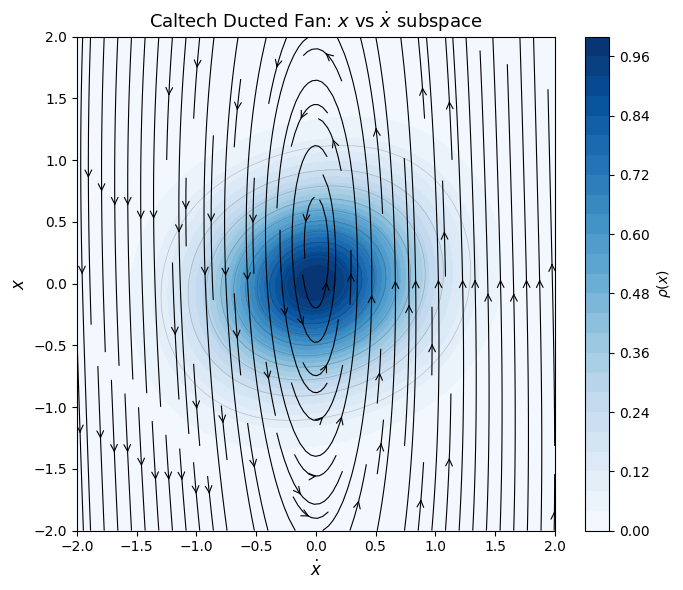

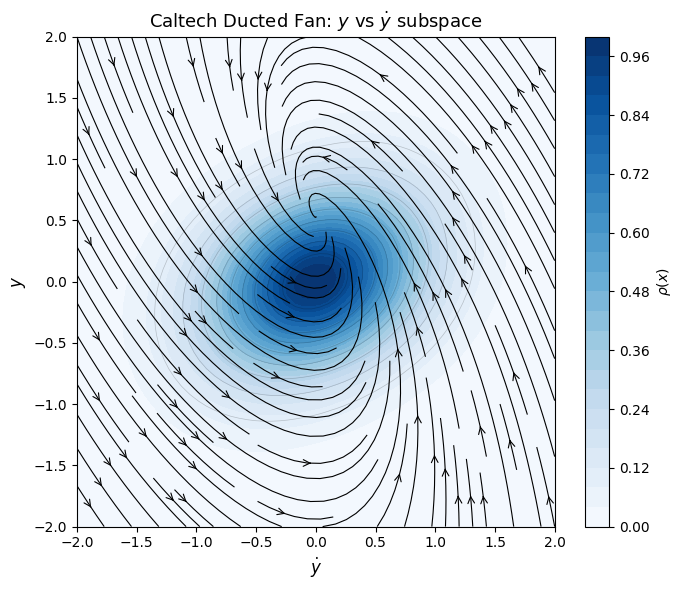

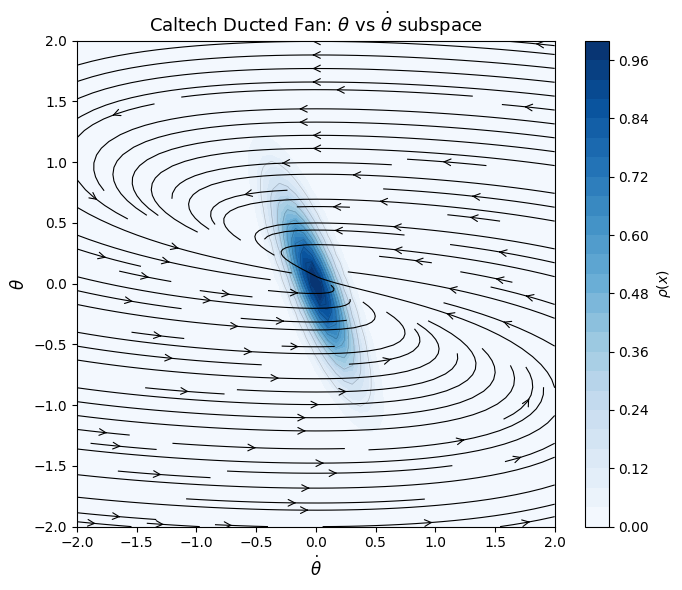

In [42]:
def plot_density_slice(a_nn, b_nn, c_nn, dim_i=0, dim_j=1,
                       fixed_vals=None, grid_size=60, state_range=2.0,
                       plot_flow=True, title_suffix=""):
    if fixed_vals is None:
        fixed_vals = torch.zeros(INPUT_DIM, device=device)

    xi_vals = torch.linspace(-state_range, state_range, grid_size)
    xj_vals = torch.linspace(-state_range, state_range, grid_size)
    Xi, Xj  = torch.meshgrid(xi_vals, xj_vals, indexing='ij')

    grid = fixed_vals.unsqueeze(0).unsqueeze(0).expand(grid_size, grid_size, -1).clone()
    grid[:, :, dim_i] = Xi
    grid[:, :, dim_j] = Xj
    grid_flat = grid.reshape(-1, INPUT_DIM)

    with torch.no_grad():
        a_vals = a_nn(grid_flat).squeeze()
        b_vals = b_nn(grid_flat)
        denom  = torch.exp(
            torch.sum(grid_flat**2, dim=1) +
            torch.sum(b_vals**2, dim=1)
        )
        rho    = (a_vals / denom).reshape(grid_size, grid_size)
        rho_max = rho.max().item()
        rho = rho / (rho_max + 1e-8)

    fig, ax = plt.subplots(figsize=(7, 6))
    state_labels = [r'$x$', r'$y$', r'$\theta$',
                    r'$\dot{x}$', r'$\dot{y}$', r'$\dot{\theta}$']

    cf = ax.contourf(Xi.numpy(), Xj.numpy(), rho.cpu().numpy(),
                     levels=30, cmap='Blues')
    ax.contour(Xi.numpy(), Xj.numpy(), rho.cpu().numpy(),
               levels=10, colors='k', linewidths=0.5, alpha=0.2)
    plt.colorbar(cf, ax=ax, label=r'$\rho(x)$')

    if plot_flow:
        # streamplot needs a regular grid and U, V arrays shaped (grid_size, grid_size)
        # NOTE: streamplot convention is U=d(x_j)/dt (horizontal) and V=d(x_i)/dt (vertical)
        # because the first axis of the grid is the x-axis of the plot
        U = torch.zeros(grid_size, grid_size)
        V = torch.zeros(grid_size, grid_size)

        with torch.no_grad():
            c_vals = c_nn(grid_flat)             # (N, 2)
            a_s    = a_nn(grid_flat).squeeze()   # (N,)
            u_vals = c_vals / a_s.unsqueeze(1)   # (N, 2)

        for k in range(grid_flat.shape[0]):
            xi_k = grid_flat[k]
            u_k  = u_vals[k]
            f_k  = f(xi_k)
            g_k  = g_matrix(xi_k)
            cl_k = f_k + g_k @ u_k              # closed-loop vector field, shape (6,)
            row = k // grid_size
            col = k % grid_size
            # streamplot: x-axis is dim_j, y-axis is dim_i
            U[row, col] = cl_k[dim_j].item()    # horizontal component
            V[row, col] = cl_k[dim_i].item()    # vertical component

        xi_np = xi_vals.numpy()   # grid for dim_i axis (y-axis of plot)
        xj_np = xj_vals.numpy()   # grid for dim_j axis (x-axis of plot)

        # streamplot(x, y, U, V): x varies along columns, y along rows
        # so pass xj_np as x, xi_np as y, and transpose U/V accordingly
        ax.streamplot(
            xj_np, xi_np,
            U.numpy(), V.numpy(),
            color='black',
            linewidth=0.8,
            arrowsize=1.2,
            density=1.2,        # increase for more stream lines, decrease for fewer
            arrowstyle='->',
        )

    ax.set_xlabel(state_labels[dim_j], fontsize=12)
    ax.set_ylabel(state_labels[dim_i], fontsize=12)
    ax.set_title(
        f"Caltech Ducted Fan: {state_labels[dim_i]} vs {state_labels[dim_j]} subspace",
        fontsize=13
    )
    ax.set_xlim(-state_range, state_range)
    ax.set_ylim(-state_range, state_range)
    plt.tight_layout()
    plt.show()


plot_density_slice(a_loaded, b_loaded, c_loaded, dim_i=0, dim_j=3)

plot_density_slice(a_loaded, b_loaded, c_loaded, dim_i=1, dim_j=4)

plot_density_slice(a_loaded, b_loaded, c_loaded, dim_i=2, dim_j=5)